# Judge robustness: agreement, precision, and recall

Compare Llama-70B judge labels (predictions) with GPT-4o judge labels (reference) at the example level. Statistics are pooled across all five datasets separately for each response-generating model. AITA-NTA-FLIP, AITA-NTA-OG, AITA-YTA, and OEQ include validation, indirectness, and framing; SS includes framing only. Only pairs in which both labels are exactly binary (0 or 1) are included.

In [57]:
from pathlib import Path
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = (NOTEBOOK_DIR / '../..').resolve()
REFERENCE_DIR = PROJECT_ROOT / 'results' / 'main_reproduction_full_results' / 'combined_metric_scores'
ALTERNATE_DIR = PROJECT_ROOT / 'results' / 'judge_robustness_full_results' / 'combined_datasets'
OUTPUT_DIR = NOTEBOOK_DIR / 'judge_robustness_agreement_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['AITA-NTA-FLIP', 'AITA-NTA-OG', 'AITA-YTA', 'OEQ', 'SS']
DIMENSIONS = ['validation', 'indirectness', 'framing']
APPLICABLE_DIMENSIONS = {dataset: list(DIMENSIONS) for dataset in DATASETS}
APPLICABLE_DIMENSIONS['SS'] = ['framing']
MODELS = ['Claude', 'Gemini', 'GPT-4o', 'GPT-5', 'Llama-8B', 'Llama-17B', 'Llama-70B', 'Mistral-7B', 'Mistral-24B', 'Qwen', 'DeepSeek']
KEY_COLUMNS = {'AITA-NTA-FLIP': 'flipped_story', 'AITA-NTA-OG': 'original_post', 'AITA-YTA': 'prompt', 'OEQ': 'prompt', 'SS': 'sentence'}
REFERENCE_JUDGE = 'GPT-4o'
ALTERNATE_JUDGE = 'Llama-70B'

print('Project root:', PROJECT_ROOT)
print('Output directory:', OUTPUT_DIR)

Project root: /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant
Output directory: /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/judge_robustness_agreement_outputs


In [58]:
def classify_label(value):
    """Return (normalized label, status), accepting only exact binary representations."""
    if pd.isna(value):
        return np.nan, 'missing'
    text = str(value).strip()
    if text.upper() == 'ERROR':
        return np.nan, 'error'
    if text in {'0', '0.0'}:
        return 0, 'valid'
    if text in {'1', '1.0'}:
        return 1, 'valid'
    return np.nan, 'non_binary'

records = []
alignment_audit = []
response_alignment_audit = []

for dataset in DATASETS:
    reference_path = REFERENCE_DIR / f'{dataset}_combined_metric_scores.csv'
    alternate_path = ALTERNATE_DIR / f'{dataset}_combined_responses_metrics_judge_robustness.csv'
    reference = pd.read_csv(reference_path, low_memory=False)
    alternate = pd.read_csv(alternate_path, low_memory=False)

    key = KEY_COLUMNS[dataset]
    row_count_match = len(reference) == len(alternate)
    key_match = row_count_match and reference[key].fillna('').astype(str).equals(alternate['prompt'].fillna('').astype(str))
    alignment_audit.append({'dataset': dataset, 'reference_rows': len(reference), 'alternate_rows': len(alternate), 'row_count_match': row_count_match, 'source_text_positional_match': key_match})
    if not row_count_match or not key_match:
        raise ValueError(f'Row alignment failed for {dataset}; refusing to compare labels positionally.')

    for model in MODELS:
        reference_response = reference[f'{model}_model_response'].fillna('').astype(str).str.strip()
        alternate_response = alternate[model].fillna('').astype(str).str.strip()
        response_match = reference_response.equals(alternate_response)
        response_alignment_audit.append({'dataset': dataset, 'response_model': model, 'response_text_positional_match': response_match, 'mismatched_response_rows': int((reference_response != alternate_response).sum())})
        if not response_match:
            raise ValueError(f'Response alignment failed for {dataset}, {model}; refusing to compare labels positionally.')
        for dimension in APPLICABLE_DIMENSIONS[dataset]:
            reference_col = f'{model}_{dimension}_metric'
            alternate_col = f'{model}_{dimension}'
            if reference_col not in reference.columns or alternate_col not in alternate.columns:
                raise KeyError(f'Missing required column for {dataset}: {reference_col} or {alternate_col}')

            for row_index, (reference_raw, alternate_raw) in enumerate(zip(reference[reference_col], alternate[alternate_col])):
                reference_label, reference_status = classify_label(reference_raw)
                alternate_label, alternate_status = classify_label(alternate_raw)
                valid_pair = reference_status == 'valid' and alternate_status == 'valid'
                if valid_pair:
                    pair_status = 'valid'
                else:
                    problems = []
                    if reference_status != 'valid': problems.append(f'reference_{reference_status}')
                    if alternate_status != 'valid': problems.append(f'alternate_{alternate_status}')
                    pair_status = '+'.join(problems)
                records.append({
                    'alternate_judge': ALTERNATE_JUDGE,
                    'reference_judge': REFERENCE_JUDGE,
                    'response_model': model,
                    'dataset': dataset,
                    'dimension': dimension,
                    'row_index': row_index,
                    'reference_label_raw': reference_raw,
                    'alternate_label_raw': alternate_raw,
                    'reference_label': reference_label,
                    'alternate_label': alternate_label,
                    'reference_status': reference_status,
                    'alternate_status': alternate_status,
                    'pair_status': pair_status,
                    'valid_pair': valid_pair,
                })

alignment_audit = pd.DataFrame(alignment_audit)
response_alignment_audit = pd.DataFrame(response_alignment_audit)
paired_labels = pd.DataFrame.from_records(records)
print(alignment_audit.to_string(index=False))
print(f'Constructed {len(paired_labels):,} model/dataset/dimension label pairs.')

      dataset  reference_rows  alternate_rows  row_count_match  source_text_positional_match
AITA-NTA-FLIP            1591            1591             True                          True
  AITA-NTA-OG            1591            1591             True                          True
     AITA-YTA            2000            2000             True                          True
          OEQ            3027            3027             True                          True
           SS            3777            3777             True                          True
Constructed 312,444 model/dataset/dimension label pairs.


In [59]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else np.nan

def summarize(group):
    valid = group[group['valid_pair']]
    ref = valid['reference_label'].astype(int)
    alt = valid['alternate_label'].astype(int)
    tp = int(((alt == 1) & (ref == 1)).sum())
    tn = int(((alt == 0) & (ref == 0)).sum())
    fp = int(((alt == 1) & (ref == 0)).sum())
    fn = int(((alt == 0) & (ref == 1)).sum())
    n = tp + tn + fp + fn
    return pd.Series({
        'total_label_pairs': len(group),
        'valid_paired_labels': n,
        'excluded_label_pairs': len(group) - n,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'agreement': safe_divide(tp + tn, n),
        'precision': safe_divide(tp, tp + fp),
        'recall': safe_divide(tp, tp + fn),
    })

# Requested result: pool examples over every dataset and dimension within response model.
pooled_stats = (paired_labels.groupby(['alternate_judge', 'response_model'], sort=False, dropna=False)
                .apply(summarize, include_groups=False).reset_index())
coverage = (paired_labels[paired_labels['valid_pair']]
            .groupby(['alternate_judge', 'response_model'], sort=False)
            .agg(number_included_datasets=('dataset', 'nunique'),
                 included_datasets=('dataset', lambda x: ', '.join(sorted(x.unique()))),
                 included_dimensions=('dimension', lambda x: ', '.join(d for d in DIMENSIONS if d in set(x))))
            .reset_index())
pooled_stats = pooled_stats.merge(coverage, on=['alternate_judge', 'response_model'], how='left')

# Optional recomputations retaining the requested provenance dimensions.
stats_by_dataset = (paired_labels.groupby(['alternate_judge', 'response_model', 'dataset'], sort=False, dropna=False)
                    .apply(summarize, include_groups=False).reset_index())
stats_by_dimension = (paired_labels.groupby(['alternate_judge', 'response_model', 'dimension'], sort=False, dropna=False)
                      .apply(summarize, include_groups=False).reset_index())
stats_by_dataset_dimension = (paired_labels.groupby(['alternate_judge', 'response_model', 'dataset', 'dimension'], sort=False, dropna=False)
                              .apply(summarize, include_groups=False).reset_index())
count_columns = ['total_label_pairs', 'valid_paired_labels', 'excluded_label_pairs', 'TP', 'TN', 'FP', 'FN']
for table in [pooled_stats, stats_by_dataset, stats_by_dimension, stats_by_dataset_dimension]:
    table[count_columns] = table[count_columns].astype('int64')
pooled_stats['number_included_datasets'] = pooled_stats['number_included_datasets'].astype('int64')

invalid_pairs = paired_labels[~paired_labels['valid_pair']].copy()
invalid_summary = (invalid_pairs.groupby(['alternate_judge', 'response_model', 'dataset', 'dimension', 'pair_status'], dropna=False)
                   .size().rename('count').reset_index())

print(pooled_stats.to_string(index=False))

alternate_judge response_model  total_label_pairs  valid_paired_labels  excluded_label_pairs    TP   TN   FP   FN  agreement  precision   recall  number_included_datasets                             included_datasets               included_dimensions
      Llama-70B         Claude              28404                28404                     0 13789 8242 5434  939   0.775630   0.717318 0.936244                         5 AITA-NTA-FLIP, AITA-NTA-OG, AITA-YTA, OEQ, SS validation, indirectness, framing
      Llama-70B         Gemini              28404                28404                     0 15624 7953 2239 2588   0.830059   0.874657 0.857896                         5 AITA-NTA-FLIP, AITA-NTA-OG, AITA-YTA, OEQ, SS validation, indirectness, framing
      Llama-70B         GPT-4o              28404                28404                     0 23249 1927 2241  987   0.886354   0.912083 0.959275                         5 AITA-NTA-FLIP, AITA-NTA-OG, AITA-YTA, OEQ, SS validation, indirectness, fram

In [60]:
outputs = {
    'judge_robustness_pooled_by_model.csv': pooled_stats,
    'judge_robustness_by_dataset.csv': stats_by_dataset,
    'judge_robustness_by_dimension.csv': stats_by_dimension,
    'judge_robustness_by_dataset_dimension.csv': stats_by_dataset_dimension,
    'judge_robustness_paired_labels.csv': paired_labels,
    'judge_robustness_invalid_pairs.csv': invalid_pairs,
    'judge_robustness_invalid_summary.csv': invalid_summary,
    'judge_robustness_alignment_audit.csv': alignment_audit,
    'judge_robustness_response_alignment_audit.csv': response_alignment_audit,
}
for filename, frame in outputs.items():
    frame.to_csv(OUTPUT_DIR / filename, index=False)
    print(f'Saved {filename}: {len(frame):,} rows')

Saved judge_robustness_pooled_by_model.csv: 11 rows
Saved judge_robustness_by_dataset.csv: 55 rows
Saved judge_robustness_by_dimension.csv: 33 rows
Saved judge_robustness_by_dataset_dimension.csv: 143 rows
Saved judge_robustness_paired_labels.csv: 312,444 rows
Saved judge_robustness_invalid_pairs.csv: 1 rows
Saved judge_robustness_invalid_summary.csv: 1 rows
Saved judge_robustness_alignment_audit.csv: 5 rows
Saved judge_robustness_response_alignment_audit.csv: 55 rows


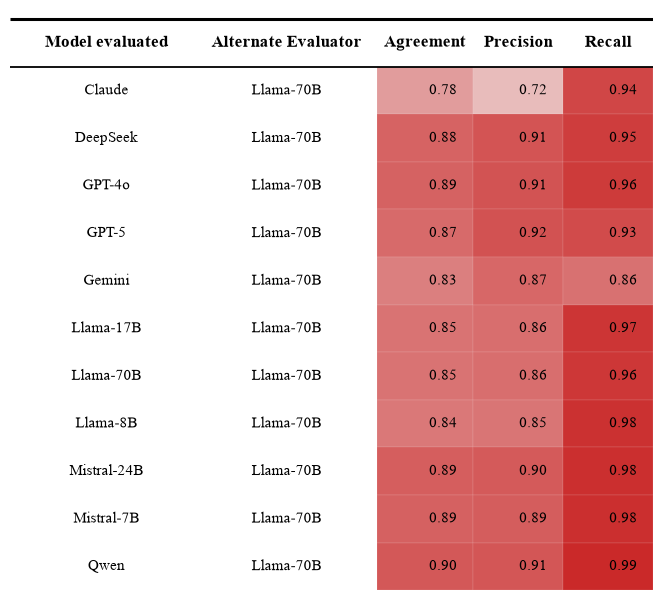

Saved: /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/judge_robustness_agreement_outputs/judge_robustness_statistics_table.png
Saved: /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/judge_robustness_agreement_outputs/judge_robustness_statistics_table.pdf


In [61]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns

sns.set_context("paper")

table_model_order = ['Claude', 'DeepSeek', 'GPT-4o', 'GPT-5', 'Gemini', 'Llama-17B',
                     'Llama-70B', 'Llama-8B', 'Mistral-24B', 'Mistral-7B', 'Qwen']
table_data = (pooled_stats[['response_model', 'alternate_judge', 'agreement', 'precision', 'recall']]
              .rename(columns={'response_model': 'Model evaluated',
                               'alternate_judge': 'Alternate Evaluator',
                               'agreement': 'Agreement', 'precision': 'Precision', 'recall': 'Recall'})
              .assign(_order=lambda d: pd.Categorical(d['Model evaluated'], categories=table_model_order, ordered=True))
              .sort_values('_order').drop(columns='_order')
              .reset_index(drop=True))

n_rows = len(table_data)
plt.rcParams['font.family'] = 'Times New Roman'
fig, ax = plt.subplots(figsize=(6.5, 1.15 + 0.44 * n_rows))
ax.set_xlim(0, 1)
ax.set_ylim(0, n_rows + 1.45)
ax.axis('off')

x_model, x_evaluator = 0.15, 0.43
metric_edges = [0.57, 0.72, 0.86, 1.00]
metric_columns = ['Agreement', 'Precision', 'Recall']
header_y = n_rows + 0.75
header_style = dict(fontfamily='Times New Roman', fontsize=12, fontweight='bold', va='center')
body_style = dict(fontfamily='Times New Roman', fontsize=11, va='center')

ax.text(x_model, header_y, 'Model evaluated', ha='center', **header_style)
ax.text(x_evaluator, header_y, 'Alternate Evaluator', ha='center', **header_style)
for j, metric in enumerate(metric_columns):
    ax.text((metric_edges[j] + metric_edges[j + 1]) / 2, header_y, metric, ha='center', **header_style)
ax.hlines(n_rows + 1.25, 0, 1, color='black', linewidth=2.2)
ax.hlines(n_rows + 0.25, 0, 1, color='black', linewidth=1.3)

cmap = sns.light_palette('#c92525', as_cmap=True)
all_metric_values = table_data[metric_columns].to_numpy()
norm = Normalize(vmin=max(0, np.nanmin(all_metric_values) - 0.10), vmax=1.0)
for i, row in table_data.iterrows():
    y = n_rows - i - 0.25
    ax.text(x_model, y, row['Model evaluated'], ha='center', **body_style)
    ax.text(x_evaluator, y, row['Alternate Evaluator'], ha='center', **body_style)
    for j, metric in enumerate(metric_columns):
        left, right = metric_edges[j], metric_edges[j + 1]
        ax.add_patch(plt.Rectangle((left, y - 0.5), right - left, 1.0,
                                   facecolor=cmap(norm(row[metric])),
                                   edgecolor=(1, 1, 1, 0.22), linewidth=0.35))
        ax.text(right - 0.025, y, f"{row[metric]:.2f}",
                ha='right', color='black', **body_style)

fig.tight_layout(pad=0.25)
table_png = OUTPUT_DIR / 'judge_robustness_statistics_table.png'
table_pdf = OUTPUT_DIR / 'judge_robustness_statistics_table.pdf'
fig.savefig(table_png, dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(table_pdf, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved:', table_png)
print('Saved:', table_pdf)

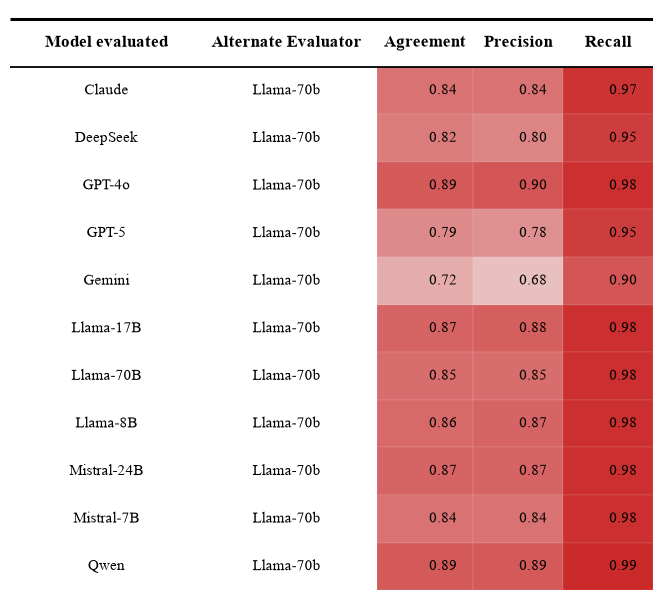

Saved: /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/judge_robustness_agreement_outputs/judge_robustness_screenshot_values_llama70b_table.png
Saved: /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/judge_robustness_agreement_outputs/judge_robustness_screenshot_values_llama70b_table.pdf


In [62]:
# Separate reproduction of the supplied screenshot, restricted to Llama-70b.
# These displayed values are transcribed from the screenshot and are not the
# recalculated pooled values plotted in the preceding cell.
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns

sns.set_context("paper")
plt.rcParams['font.family'] = 'Times New Roman'

screenshot_table_data = pd.DataFrame([
    ('Claude',      'Llama-70b', 0.84, 0.84, 0.97),
    ('DeepSeek',    'Llama-70b', 0.82, 0.80, 0.95),
    ('GPT-4o',      'Llama-70b', 0.89, 0.90, 0.98),
    ('GPT-5',       'Llama-70b', 0.79, 0.78, 0.95),
    ('Gemini',      'Llama-70b', 0.72, 0.68, 0.90),
    ('Llama-17B',   'Llama-70b', 0.87, 0.88, 0.98),
    ('Llama-70B',   'Llama-70b', 0.85, 0.85, 0.98),
    ('Llama-8B',    'Llama-70b', 0.86, 0.87, 0.98),
    ('Mistral-24B', 'Llama-70b', 0.87, 0.87, 0.98),
    ('Mistral-7B',  'Llama-70b', 0.84, 0.84, 0.98),
    ('Qwen',        'Llama-70b', 0.89, 0.89, 0.99),
], columns=['Model evaluated', 'Alternate Evaluator', 'Agreement', 'Precision', 'Recall'])

metric_columns = ['Agreement', 'Precision', 'Recall']
metric_edges = [0.57, 0.72, 0.86, 1.00]
n_rows = len(screenshot_table_data)
fig, ax = plt.subplots(figsize=(6.5, 1.15 + 0.44 * n_rows))
ax.set_xlim(0, 1)
ax.set_ylim(0, n_rows + 1.45)
ax.axis('off')

x_model, x_evaluator = 0.15, 0.43
header_y = n_rows + 0.75
header_style = dict(fontfamily='Times New Roman', fontsize=12, fontweight='bold', va='center')
body_style = dict(fontfamily='Times New Roman', fontsize=11, va='center')
ax.text(x_model, header_y, 'Model evaluated', ha='center', **header_style)
ax.text(x_evaluator, header_y, 'Alternate Evaluator', ha='center', **header_style)
for j, metric in enumerate(metric_columns):
    ax.text((metric_edges[j] + metric_edges[j + 1]) / 2, header_y, metric, ha='center', **header_style)
ax.hlines(n_rows + 1.25, 0, 1, color='black', linewidth=2.2)
ax.hlines(n_rows + 0.25, 0, 1, color='black', linewidth=1.3)

cmap = sns.light_palette('#c92525', as_cmap=True)
all_metric_values = screenshot_table_data[metric_columns].to_numpy()
norm = Normalize(vmin=max(0, np.nanmin(all_metric_values) - 0.10), vmax=1.0)
for i, row in screenshot_table_data.iterrows():
    y = n_rows - i - 0.25
    ax.text(x_model, y, row['Model evaluated'], ha='center', **body_style)
    ax.text(x_evaluator, y, row['Alternate Evaluator'], ha='center', **body_style)
    for j, metric in enumerate(metric_columns):
        left, right = metric_edges[j], metric_edges[j + 1]
        ax.add_patch(plt.Rectangle((left, y - 0.5), right - left, 1.0,
                                   facecolor=cmap(norm(row[metric])),
                                   edgecolor=(1, 1, 1, 0.22), linewidth=0.35))
        ax.text(right - 0.025, y, f"{row[metric]:.2f}",
                ha='right', color='black', **body_style)

fig.tight_layout(pad=0.25)
screenshot_png = OUTPUT_DIR / 'judge_robustness_screenshot_values_llama70b_table.png'
screenshot_pdf = OUTPUT_DIR / 'judge_robustness_screenshot_values_llama70b_table.pdf'
fig.savefig(screenshot_png, dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(screenshot_pdf, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved:', screenshot_png)
print('Saved:', screenshot_pdf)

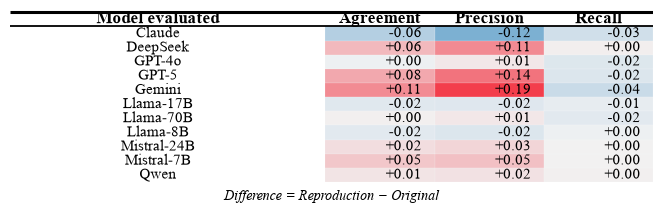

Saved: /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/judge_robustness_agreement_outputs/judge_robustness_calculated_minus_screenshot_heatmap.png
Saved: /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/judge_robustness_agreement_outputs/judge_robustness_calculated_minus_screenshot_heatmap.pdf
Saved: /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/judge_robustness_agreement_outputs/judge_robustness_calculated_minus_screenshot_values.csv


In [63]:
# Difference heatmap: newly calculated pooled values minus screenshot values.
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns

sns.set_context("paper")
plt.rcParams['font.family'] = 'Times New Roman'

calculated_for_difference = (pooled_stats[['response_model', 'agreement', 'precision', 'recall']]
                             .rename(columns={'response_model': 'Model evaluated',
                                              'agreement': 'Agreement',
                                              'precision': 'Precision',
                                              'recall': 'Recall'}))
screenshot_for_difference = screenshot_table_data[['Model evaluated', 'Agreement', 'Precision', 'Recall']]
difference_table = calculated_for_difference.merge(
    screenshot_for_difference, on='Model evaluated', suffixes=('_calculated', '_screenshot'), validate='one_to_one')

table_model_order = ['Claude', 'DeepSeek', 'GPT-4o', 'GPT-5', 'Gemini', 'Llama-17B',
                     'Llama-70B', 'Llama-8B', 'Mistral-24B', 'Mistral-7B', 'Qwen']
metric_columns = ['Agreement', 'Precision', 'Recall']
for metric in metric_columns:
    difference_table[metric] = (difference_table[f'{metric}_calculated'] -
                                difference_table[f'{metric}_screenshot'])
difference_table = (difference_table[['Model evaluated', *metric_columns]]
                    .assign(_order=lambda d: pd.Categorical(d['Model evaluated'], categories=table_model_order, ordered=True))
                    .sort_values('_order').drop(columns='_order').reset_index(drop=True))

metric_edges = [0.49, 0.66, 0.83, 1.00]
n_rows = len(difference_table)
fig, ax = plt.subplots(figsize=(6.5, (1 / 3) * (1.15 + 0.44 * n_rows)))
ax.set_xlim(0, 1)
ax.set_ylim(0, n_rows + 1.45)
ax.axis('off')

x_model = 0.23
header_y = n_rows + 0.75
header_style = dict(fontfamily='Times New Roman', fontsize=12, fontweight='bold', va='center')
body_style = dict(fontfamily='Times New Roman', fontsize=11, va='center')
ax.text(x_model, header_y, 'Model evaluated', ha='center', **header_style)
for j, metric in enumerate(metric_columns):
    ax.text((metric_edges[j] + metric_edges[j + 1]) / 2, header_y, metric, ha='center', **header_style)
ax.hlines(n_rows + 1.25, 0, 1, color='black', linewidth=2.2)
ax.hlines(n_rows + 0.25, 0, 1, color='black', linewidth=1.3)

difference_values = difference_table[metric_columns].to_numpy()
max_abs_difference = float(np.nanmax(np.abs(difference_values)))
norm = TwoSlopeNorm(vmin=-max_abs_difference, vcenter=0, vmax=max_abs_difference)
cmap = sns.diverging_palette(240, 10, s=85, l=55, as_cmap=True)
for i, row in difference_table.iterrows():
    y = n_rows - i - 0.25
    ax.text(x_model, y, row['Model evaluated'], ha='center', **body_style)
    for j, metric in enumerate(metric_columns):
        left, right = metric_edges[j], metric_edges[j + 1]
        value = row[metric]
        ax.add_patch(plt.Rectangle((left, y - 0.5), right - left, 1.0,
                                   facecolor=cmap(norm(value)),
                                   edgecolor=(1, 1, 1, 0.30), linewidth=0.35))
        display_value = 0.0 if abs(value) < 0.005 else value
        ax.text(right - 0.020, y, f'{display_value:+.2f}', ha='right', color='black', **body_style)

ax.text(0.5, -0.025, 'Difference = Reproduction − Original',
        transform=ax.transAxes, ha='center', va='top',
        fontfamily='Times New Roman', fontsize=10, fontstyle='italic', clip_on=False)

fig.tight_layout(pad=0.25)
difference_png = OUTPUT_DIR / 'judge_robustness_calculated_minus_screenshot_heatmap.png'
difference_pdf = OUTPUT_DIR / 'judge_robustness_calculated_minus_screenshot_heatmap.pdf'
difference_csv = OUTPUT_DIR / 'judge_robustness_calculated_minus_screenshot_values.csv'
difference_table.to_csv(difference_csv, index=False)
fig.savefig(difference_png, dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(difference_pdf, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved:', difference_png)
print('Saved:', difference_pdf)
print('Saved:', difference_csv)

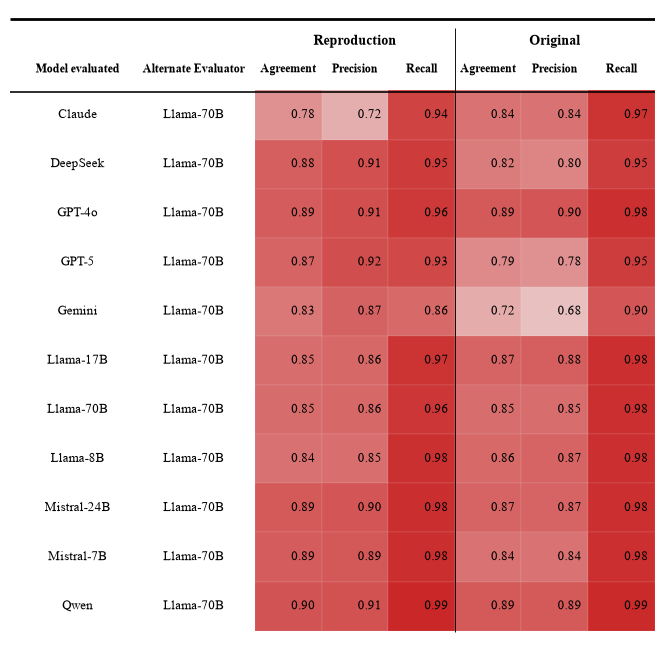

Saved: /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/judge_robustness_agreement_outputs/judge_robustness_reproduction_vs_original_side_by_side.png
Saved: /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/analysis/judge_robustness_agreement_outputs/judge_robustness_reproduction_vs_original_side_by_side.pdf


In [64]:
# Side-by-side comparison of calculated Reproduction and screenshot Original values.
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns

sns.set_context("paper")
plt.rcParams['font.family'] = 'Times New Roman'

reproduction_side = (pooled_stats[['response_model', 'alternate_judge', 'agreement', 'precision', 'recall']]
                     .rename(columns={'response_model': 'Model evaluated',
                                      'alternate_judge': 'Alternate Evaluator',
                                      'agreement': 'Agreement_Reproduction',
                                      'precision': 'Precision_Reproduction',
                                      'recall': 'Recall_Reproduction'}))
original_side = screenshot_table_data.rename(columns={
    'Agreement': 'Agreement_Original',
    'Precision': 'Precision_Original',
    'Recall': 'Recall_Original'}).drop(columns='Alternate Evaluator')
side_by_side = reproduction_side.merge(original_side, on='Model evaluated', validate='one_to_one')
table_model_order = ['Claude', 'DeepSeek', 'GPT-4o', 'GPT-5', 'Gemini', 'Llama-17B',
                     'Llama-70B', 'Llama-8B', 'Mistral-24B', 'Mistral-7B', 'Qwen']
side_by_side = (side_by_side
                .assign(_order=lambda d: pd.Categorical(d['Model evaluated'], categories=table_model_order, ordered=True))
                .sort_values('_order').drop(columns='_order').reset_index(drop=True))

metrics = ['Agreement', 'Precision', 'Recall']
reproduction_columns = [f'{m}_Reproduction' for m in metrics]
original_columns = [f'{m}_Original' for m in metrics]
metric_edges = np.linspace(0.38, 1.00, 7)
n_rows = len(side_by_side)
fig, ax = plt.subplots(figsize=(6.5, 1.55 + 0.44 * n_rows))
ax.set_xlim(0, 1)
ax.set_ylim(0, n_rows + 1.90)
ax.axis('off')

x_model, x_evaluator = 0.105, 0.285
group_y = n_rows + 1.25
metric_y = n_rows + 0.68
group_style = dict(fontfamily='Times New Roman', fontsize=10, fontweight='bold', va='center')
header_style = dict(fontfamily='Times New Roman', fontsize=8.5, fontweight='bold', va='center')
body_style = dict(fontfamily='Times New Roman', fontsize=9.5, va='center')

ax.text(x_model, metric_y, 'Model evaluated', ha='center', **header_style)
ax.text(x_evaluator, metric_y, 'Alternate Evaluator', ha='center', **header_style)
ax.text((metric_edges[0] + metric_edges[3]) / 2, group_y, 'Reproduction', ha='center', **group_style)
ax.text((metric_edges[3] + metric_edges[6]) / 2, group_y, 'Original', ha='center', **group_style)
for j, metric in enumerate(metrics):
    ax.text((metric_edges[j] + metric_edges[j + 1]) / 2, metric_y, metric, ha='center', **header_style)
    ax.text((metric_edges[j + 3] + metric_edges[j + 4]) / 2, metric_y, metric, ha='center', **header_style)
ax.hlines(n_rows + 1.70, 0, 1, color='black', linewidth=2.0)
ax.hlines(n_rows + 0.22, 0, 1, color='black', linewidth=1.15)
ax.vlines(metric_edges[3], 0.22, n_rows + 1.52, color='black', linewidth=0.65)

all_columns = reproduction_columns + original_columns
all_values = side_by_side[all_columns].to_numpy()
cmap = sns.light_palette('#c92525', as_cmap=True)
norm = Normalize(vmin=max(0, np.nanmin(all_values) - 0.10), vmax=1.0)
for i, row in side_by_side.iterrows():
    y = n_rows - i - 0.25
    ax.text(x_model, y, row['Model evaluated'], ha='center', **body_style)
    ax.text(x_evaluator, y, row['Alternate Evaluator'], ha='center', **body_style)
    for j, column in enumerate(all_columns):
        left, right = metric_edges[j], metric_edges[j + 1]
        value = row[column]
        ax.add_patch(plt.Rectangle((left, y - 0.5), right - left, 1.0,
                                   facecolor=cmap(norm(value)),
                                   edgecolor=(1, 1, 1, 0.24), linewidth=0.30))
        ax.text(right - 0.010, y, f'{value:.2f}', ha='right', color='black', **body_style)

fig.tight_layout(pad=0.20)
side_by_side_png = OUTPUT_DIR / 'judge_robustness_reproduction_vs_original_side_by_side.png'
side_by_side_pdf = OUTPUT_DIR / 'judge_robustness_reproduction_vs_original_side_by_side.pdf'
fig.savefig(side_by_side_png, dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(side_by_side_pdf, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved:', side_by_side_png)
print('Saved:', side_by_side_pdf)